# K-Means Clustering

K-Means Clustering is a clustering algorithm that takes unclassified data and attempts to classify it into $k$ clusters based on distance.

## Algorithm

1. First, randomly select $k$ initial centroids as datapoints.
2. Next, associate each datapoint with its nearest centroid.
3. Now, find the centroid of the data associated with each datapoint by taking the mean of the associated datapoints, and then update the centroids based on these means.
4. Repeat this for some set number of iterations, and return the associations created in the final iteration.

## Imports

In [190]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import BoundaryNorm
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score
import random

from sklearn.datasets import make_classification

import struct

sns.set_theme()

## Data Preprocessing
We will load in the AutoMPG data that we created in the preprocessing step:


In [159]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/AutoMPG-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
train_X

array([[ 1.49630792,  1.08923273,  0.66835485, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.50162428,  1.58460471, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.19472824,  1.1919262 , ...,  0.77258661,
        -0.46138749, -0.49701778],
       ...,
       [-0.85524411, -0.69460048,  0.27567634, ..., -1.29110112,
         2.16192996, -0.49701778],
       [ 0.3205319 , -0.29179943,  0.74689055, ..., -1.29110112,
         2.16192996, -0.49701778],
       [-0.85524411, -1.00149651, -0.87618062, ..., -1.29110112,
         2.16192996, -0.49701778]], shape=(279, 8))

Create X dataset:

In [164]:
X = np.vstack((train_X, test_X))
y = np.vstack((train_y[:, np.newaxis], test_y[:, np.newaxis]))
X = np.hstack((X[:, 2:3], y))
X

array([[ 6.68354853e-01, -7.05550657e-01],
       [ 1.58460471e+00, -1.08937947e+00],
       [ 1.19192620e+00, -7.05550657e-01],
       [ 1.19192620e+00, -9.61436534e-01],
       [ 9.30140526e-01, -8.33493595e-01],
       [ 2.44849743e+00, -1.08937947e+00],
       [ 3.02442592e+00, -1.21732241e+00],
       [ 2.89353308e+00, -1.21732241e+00],
       [ 3.15531875e+00, -1.21732241e+00],
       [ 2.23906889e+00, -1.08937947e+00],
       [ 1.71549755e+00, -1.08937947e+00],
       [ 1.45371187e+00, -1.21732241e+00],
       [ 1.19192620e+00, -1.08937947e+00],
       [ 3.15531875e+00, -1.21732241e+00],
       [-2.47895005e-01,  6.21069742e-02],
       [-2.47895005e-01, -1.93778903e-01],
       [-1.95537871e-01, -7.05550657e-01],
       [-5.09680679e-01, -3.21721841e-01],
       [-4.31144977e-01,  4.45935790e-01],
       [-1.53064481e+00,  3.17992851e-01],
       [-4.57323544e-01,  1.90049913e-01],
       [-3.78787842e-01,  6.21069742e-02],
       [-2.47895005e-01,  1.90049913e-01],
       [ 2.

Create visualization tool:

In [178]:
def display_cluster_data(X, y=None, show_color = True, centroids=None):
    if show_color:
        # first create color map
        num_blobs = len(np.unique(y))
        cmap = colormaps['Greens']
        cmap_norm = BoundaryNorm([i for i in range(num_blobs)], cmap.N)
        plt.scatter(X[:, 0], X[:, 1], c=y+1, s=3, cmap=cmap, norm=cmap_norm)
        if centroids is not None:
            plt.scatter(centroids[:, 0], centroids[:, 1], c=[i+1 for i in range(num_blobs)], s=25, cmap=cmap, norm=cmap_norm, marker='s')
    else:
        plt.scatter(X[:, 0], X[:, 1], s=3)

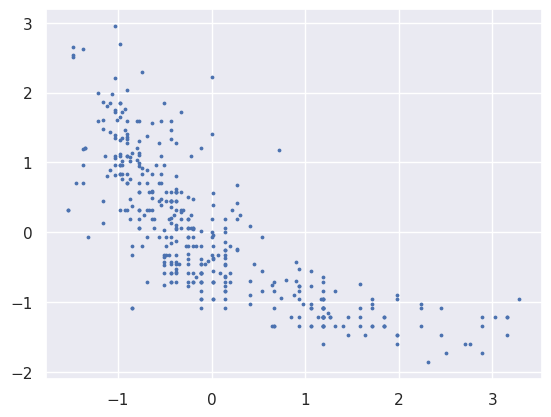

In [179]:
display_cluster_data(X, y, show_color=False)
plt.show()

## Implementation

In [180]:
def euclidean_distance(p, q):
    return np.sqrt((p - q) @ (p - q))

In [181]:
def classify_with_centers(X, centroids, dist_func):
    y_hat = np.empty((np.shape(X)[0]))
    for i in range(np.shape(X)[0]):
        dists = []
        for j in range(len(centroids)):
            centroid = centroids[j]
            dists.append(dist_func(X[i, :], centroid))
        y_hat[i] = np.argmin(dists)
    return y_hat

def update_centroids(X, classifications, num_centroids):
    new_centroids = np.empty((num_centroids, np.shape(X)[1]))
    for j in range(num_centroids):
        # first build new centroid from data with matching classification
        classified_points = []
        for i in range(np.shape(X)[0]):
            if classifications[i] == j:
                classified_points.append(X[i, :])
        new_points = np.empty((len(classified_points), np.shape(X)[1]))
        for (i, point) in enumerate(classified_points):
            new_points[i, :] = point
        new_centroids[j, :] = np.mean(new_points, axis=0)
    return new_centroids
        

def K_means_clustering(X, num_iter, num_centroids, dist_func=euclidean_distance):
    # first select random centroids
    rng = np.random.default_rng(seed=42)
    centroids = np.array(rng.choice(X, size=num_centroids, replace=False))
    for iter in range(num_iter):
        classifications = classify_with_centers(X, centroids, dist_func)
        new_centroids = update_centroids(X, classifications, num_centroids)
        centroids = new_centroids
    return classify_with_centers(X, centroids, dist_func), centroids

## Data Analysis

First, we plot the data with centroids, varying the number of clusters:

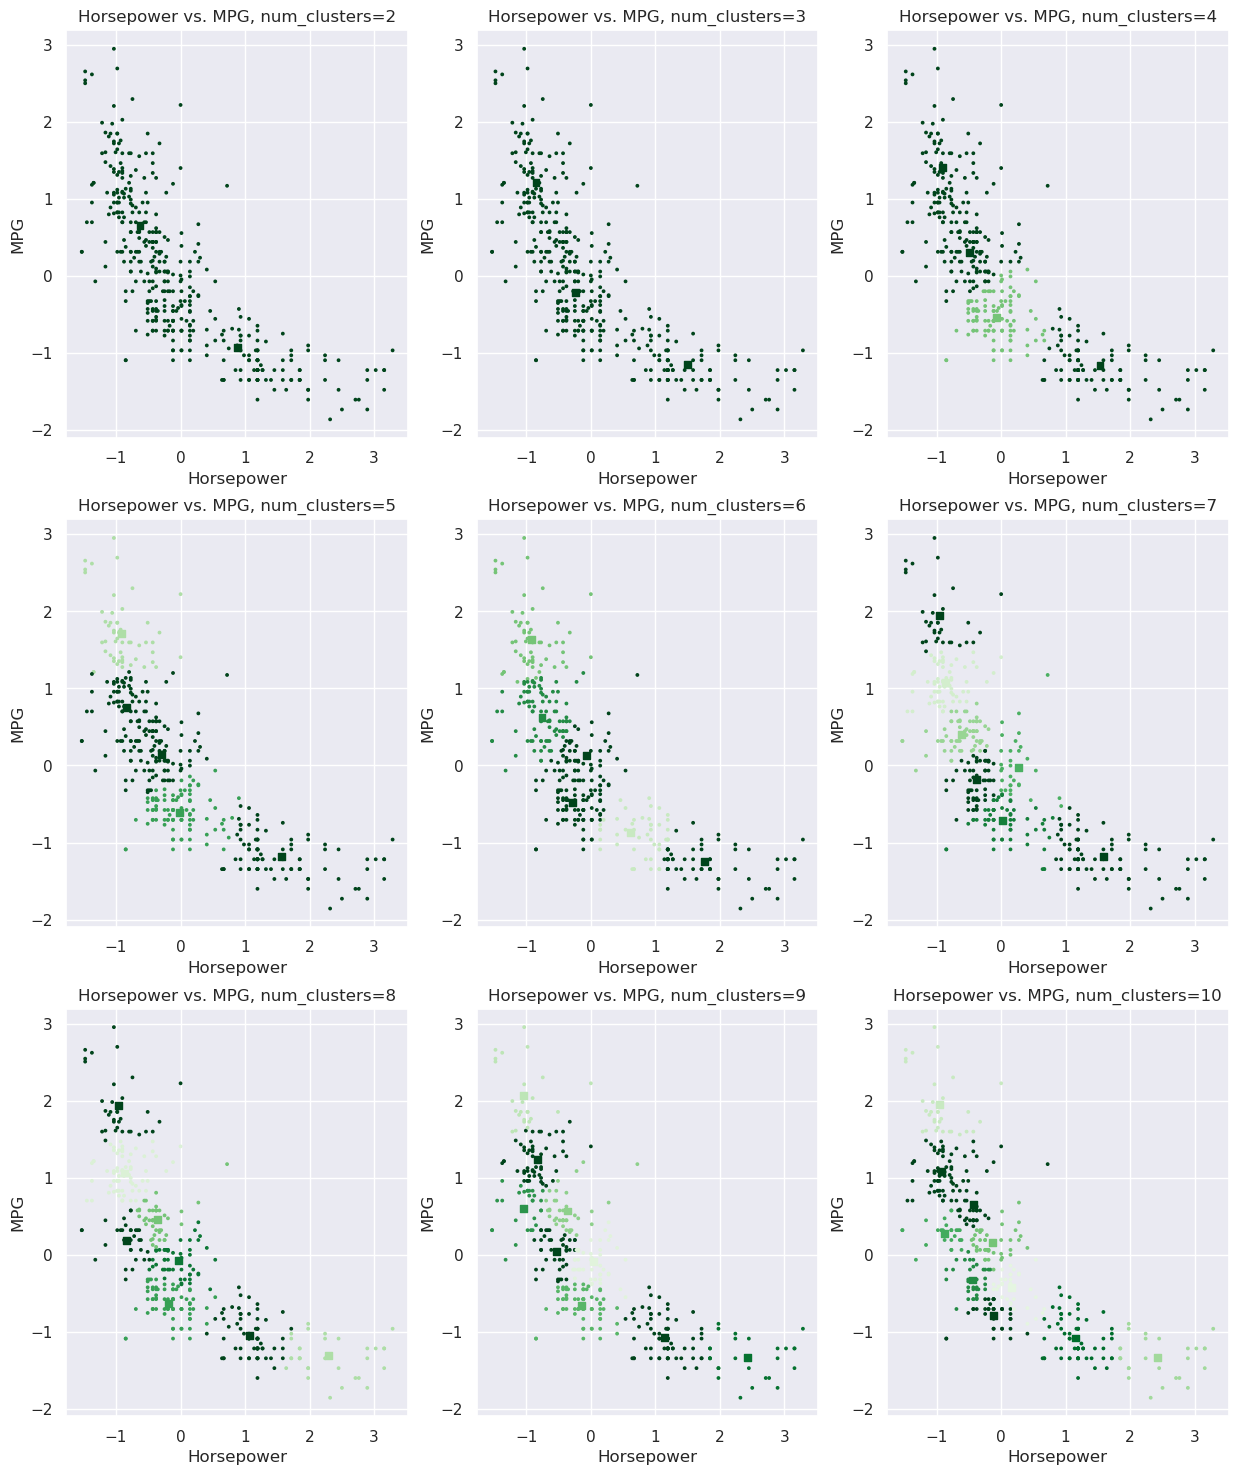

In [195]:
fig, axs = plt.subplots(3, 3, figsize = (15, 18))
mse_vals = []
num_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
scores = []

for (k, clusters) in enumerate(num_clusters):
    y_hat, centroids = K_means_clustering(X, 10, clusters)
    cmap = colormaps['Greens']
    i, j = k // 3, k % 3
    cmap_norm = BoundaryNorm([i for i in range(clusters)], cmap.N)
    axs[i, j].scatter(X[:, 0], X[:, 1], c=y_hat+1, s=3, cmap=cmap, norm=cmap_norm)
    axs[i, j].set_xlabel("Horsepower")
    axs[i, j].set_ylabel("MPG")
    axs[i, j].set_title(f"Horsepower vs. MPG, num_clusters={clusters}")
    axs[i, j].scatter(centroids[:, 0], centroids[:, 1], c=[i+1 for i in range(clusters)], s=25, cmap=cmap, norm=cmap_norm, marker='s')

    scores.append(silhouette_score(X, y_hat))
plt.show()

Now we display the silhouette score for each number of clusters. Where $a$ is the mean intra-cluster distance and $b$ is the mean nearest-cluster distance for a given sample, the sillhouette score for a sample is $\frac{b-a}{max(a,b)}$. We display the mean silhouette score across every dataset sample.

In [194]:
for (j, score) in enumerate(scores):
    print(f"Number of clusters {num_clusters[j]:2d}: Silhouette score {score: 1.3f}")

Number of clusters  2: Silhouette score  0.489
Number of clusters  3: Silhouette score  0.510
Number of clusters  4: Silhouette score  0.439
Number of clusters  5: Silhouette score  0.390
Number of clusters  6: Silhouette score  0.336
Number of clusters  7: Silhouette score  0.361
Number of clusters  8: Silhouette score  0.385
Number of clusters  9: Silhouette score  0.364
Number of clusters 10: Silhouette score  0.366


Here, we can see that 3 clusters has the highest silhouette score.